# Model Comparison: Mushroom Classification

This notebook compares the performance of three classification models:

- Decision Tree
- Random Forest
- Naive Bayes

We evaluate the models using accuracy, precision, recall, F1-score, and confusion matrices. We also analyze false negatives, which are critical in this problem since misclassifying a poisonous mushroom as edible can be dangerous.

In [49]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [50]:
# Load data
df = pd.read_csv("../sources/data/processed_mushrooms.csv")

X = df.drop("class", axis=1)
y = df["class"]

In [51]:
# Train/Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [52]:
# Train all models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import CategoricalNB

# Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Naive Bayes
nb = CategoricalNB()
nb.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None
,min_categories,None


In [53]:
# Make predictions
y_pred_dt = dt.predict(X_test)
y_pred_rf = rf.predict(X_test)
y_pred_nb = nb.predict(X_test)

In [54]:
# Model Evaluation Comparison Table
comparison_df = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest", "Naive Bayes"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_nb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_nb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_nb)
    ],
    "F1-score": [
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_nb)
    ]
})

comparison_df

,Model,Accuracy,Precision,Recall,F1-score
0,Decision Tree,1.000000,1.000000,1.000000,1.000000
1,Random Forest,1.000000,1.000000,1.000000,1.000000
2,Naive Bayes,0.945846,0.990127,0.896552,0.941019


### Model Performance Analysis

The comparison results show that both the Decision Tree and Random Forest models achieved perfect performance across all evaluation metrics, including accuracy, precision, recall, and F1-score. This indicates that these models were able to completely separate edible and poisonous mushrooms without any misclassifications.

In contrast, the Naive Bayes model achieved slightly lower performance, with an accuracy of approximately 0.946 and an F1-score of 0.941. While the precision is very high (0.99), the recall is lower (0.897), indicating that the model failed to correctly identify some poisonous mushrooms.

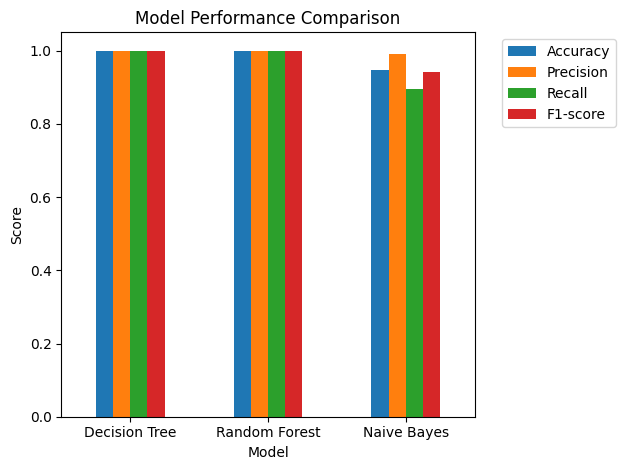

In [55]:
# Plot Model Performance Comparison
comparison_df.set_index("Model").plot(kind="bar")
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

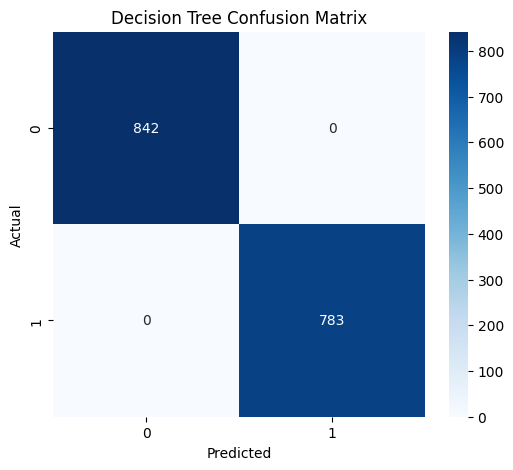

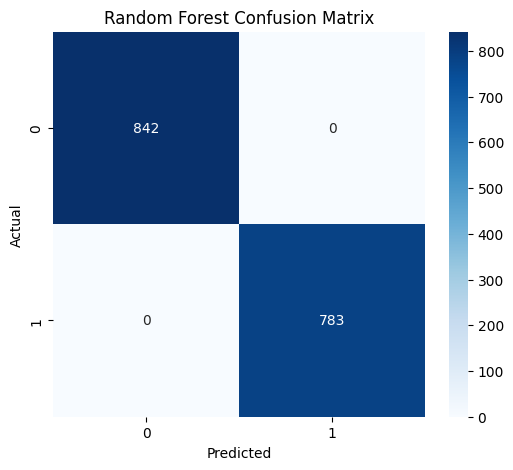

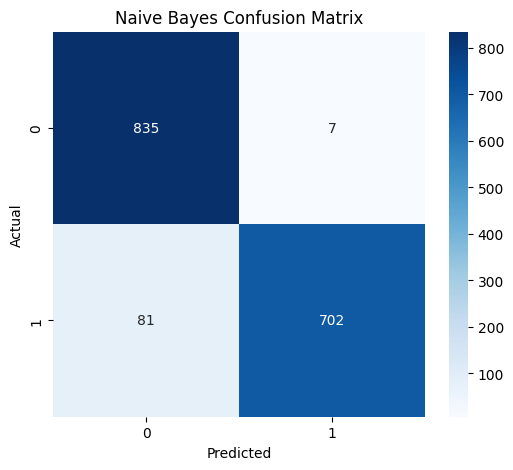

In [56]:
# Confusion Matrix For Each Model

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Decision Tree
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,5))
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")
plt.show()

# Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

# Naive Bayes
cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(6,5))
sns.heatmap(cm_nb, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Naive Bayes Confusion Matrix")
plt.show()

In [57]:
# False Negative Analysis

cm_dt = confusion_matrix(y_test, y_pred_dt)
cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_nb = confusion_matrix(y_test, y_pred_nb)

print("Decision Tree False Negatives:", cm_dt[1][0])
print("Random Forest False Negatives:", cm_rf[1][0])
print("Naive Bayes False Negatives:", cm_nb[1][0])

Decision Tree False Negatives: 0
Random Forest False Negatives: 0
Naive Bayes False Negatives: 81


### False Positive Analysis (Naive Bayes)

The Naive Bayes model produced 7 false positives, meaning that 7 edible mushrooms were incorrectly classified as poisonous. While this type of error does not pose a safety risk, it reduces the model’s usability by incorrectly labeling safe mushrooms as unsafe.

Compared to false negatives, false positives are less critical in this problem because they do not lead to harmful outcomes. However, they still indicate that the model is not perfectly accurate and may be overly conservative in some cases.

Overall, while the Naive Bayes model produces a small number of false positives, the more significant issue is the high number of false negatives, which makes it less suitable for this classification task.

### False Negative Analysis

False negatives represent cases where a poisonous mushroom is incorrectly classified as edible, which is the most critical type of error in this problem.

- Decision Tree False Negatives: 0  
- Random Forest False Negatives: 0  
- Naive Bayes False Negatives: 81  

The Decision Tree and Random Forest models produced zero false negatives, meaning they did not misclassify any poisonous mushrooms as edible. This is an important result, as it indicates that these models are highly reliable for this classification task where incorrect predictions can have serious consequences.

However, the Naive Bayes model produced 81 false negatives, meaning it incorrectly classified 81 poisonous mushrooms as edible. This highlights a significant limitation of the Naive Bayes approach for this dataset.

### Interpretation

The superior performance of the Decision Tree and Random Forest models suggests that the mushroom dataset contains strong patterns that can be captured by models capable of learning feature interactions. Tree-based models are able to model complex relationships between features, which allows them to achieve perfect classification.

On the other hand, Naive Bayes assumes that features are independent, which is not true for this dataset. Many mushroom characteristics are correlated, and this assumption limits the model’s ability to correctly classify all instances.

Overall, these results indicate that tree-based models are more suitable for this classification task, while Naive Bayes serves as a simpler baseline with lower performance.

In [58]:
print(type(nb.feature_log_prob_))
print(len(nb.feature_log_prob_))
print(nb.feature_log_prob_[0].shape)
print(X.columns.tolist())

<class 'list'>
21
(2, 6)
['cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-color', 'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat']


# Feature Importance Analysis

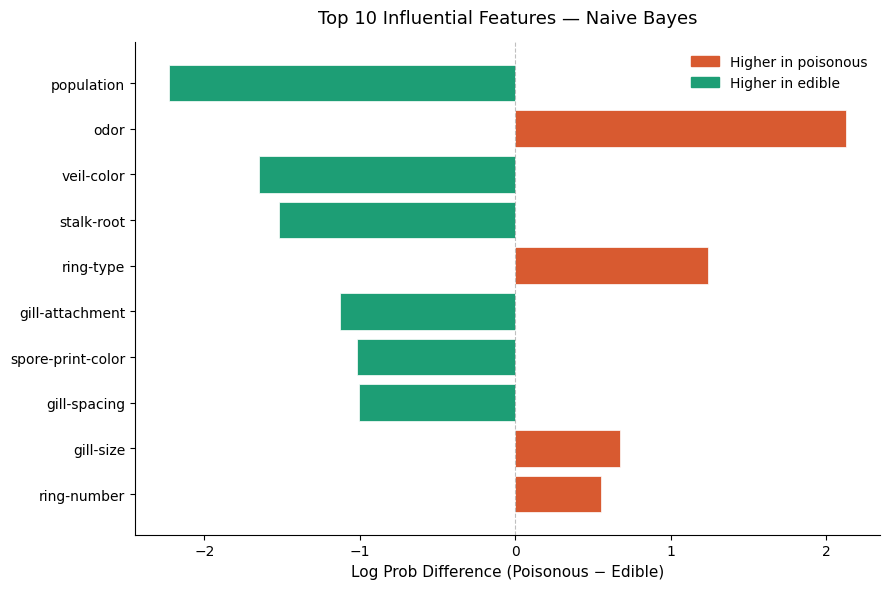

In [59]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# Correct structure: feature_log_prob_[feature][class]
feature_diff = np.array([
    nb.feature_log_prob_[i][1].mean() - nb.feature_log_prob_[i][0].mean()
    for i in range(len(X.columns))
])

feature_names = X.columns
top_idx = np.argsort(np.abs(feature_diff))[-10:]
top_features = feature_names[top_idx]
top_values = feature_diff[top_idx]

colors = ['#D85A30' if v > 0 else '#1D9E75' for v in top_values]
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_features, top_values, color=colors, edgecolor='white', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xlabel("Log Prob Difference (Poisonous − Edible)", fontsize=11)
ax.set_title("Top 10 Influential Features — Naive Bayes", fontsize=13, pad=14)
ax.spines[['top','right']].set_visible(False)

legend = [Patch(color='#D85A30', label='Higher in poisonous'),
          Patch(color='#1D9E75', label='Higher in edible')]
ax.legend(handles=legend, fontsize=10, frameon=False)
plt.tight_layout()
plt.show()

### Interpretation
The feature importance chart reveals that odor is the strongest indicator of a poisonous mushroom, while population is the strongest indicator of an edible one. This aligns with real world knowledge, as odor is widely considered one of the most reliable ways to distinguish poisonous mushrooms from edible ones.
Features like gill-color and spore-print-color also appear in the top 10, suggesting that visual characteristics play a meaningful role in the model's classification. However, because Naive Bayes assumes feature independence, it cannot capture interactions between these features the way a decision tree or random forest would. Despite this limitation, the features the model identified as most influential are consistent with domain knowledge, which suggests the model is learning meaningful patterns even under its simplifying assumptions.

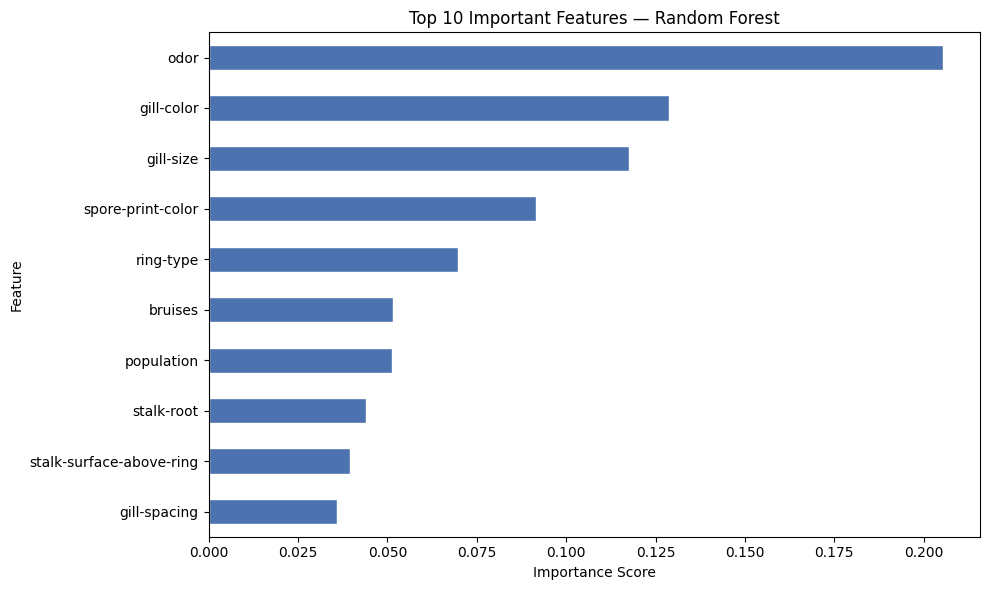

In [60]:
import pandas as pd
import matplotlib.pyplot as plt

# Load RF feature importance from the results folder
rf_fi_df = pd.read_csv("../results/random_forest_feature_importance.csv", index_col=0)

# Convert to Series
rf_fi = rf_fi_df.iloc[:, 0]

# Sort and get top 10 features
rf_fi = rf_fi.sort_values(ascending=False)
top_features = rf_fi.head(10)

# Plot
plt.figure(figsize=(10,6))
top_features.iloc[::-1].plot(kind='barh', color='#4C72B0', edgecolor='white')
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Top 10 Important Features — Random Forest")
plt.tight_layout()
plt.show()

### Interpretation

The feature “odor” stands out as the most influential feature, indicating that smell is the strongest predictor of whether a mushroom is poisonous. Following that, visual characteristics like gill-color, gill-size, and spore-print-color also contribute significantly, suggesting that appearance also plays an important role in classification. Secondary features such as ring-type, bruises, population, and stalk-related traits provide additional, though smaller, predictive power. Overall, the model relies primarily on sensory and morphological traits, with odor being the dominant factor.